Goal: first, discover aiming strategies (unsupervised), then see if we can predict a condition like distance from the aiming kinematics (supervised).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
df_aiming = pd.read_csv("C:/CourseWork/Classifying_grip_strategies_ml/data/02_processed/aiming_master_dataset.csv")

print("Aiming Dataset loaded successfully")
print(f"Dateset shape: {df_aiming.shape}")

Aiming Dataset loaded successfully
Dateset shape: (2423, 213)


In [4]:
# Cleanup columns
df_aiming = df_aiming.drop(columns=["DOB", "Gender", "Dominant.Eye"], errors="ignore")

In [5]:
# Feature Selection
identifier_cols = ["subjName", "trialN"]
condition_cols = ["visCond", "surface", "distance"]

kinematic_features = df_aiming.select_dtypes(include=np.number).columns.tolist()
kinematic_features = [col for col in kinematic_features if col not in identifier_cols]

print(f"\nIdentified {len(kinematic_features)} kinematic features")

# Scaling Kinematic Features
X_kinematic = df_aiming[kinematic_features].copy()

# Handle any potential missing values 
if X_kinematic.isnull().sum().sum() > 0:
    print("\nWarning: Missing values detected. Filling with the mean")
    X_kinematic = X_kinematic.fillna(X_kinematic.mean())

# Scaling
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X_kinematic)
print("\nKinematic features have been scaled")


Identified 205 kinematic features

Kinematic features have been scaled


# Phase 1: Unsupervised Learning

In [6]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA reduced dimensions to {pca.n_components_} components, explaining {np.sum(pca.explained_variance_ratio_):.2f}% of variance")

PCA reduced dimensions to 59 components, explaining 0.95% of variance


## Cluster Analysis

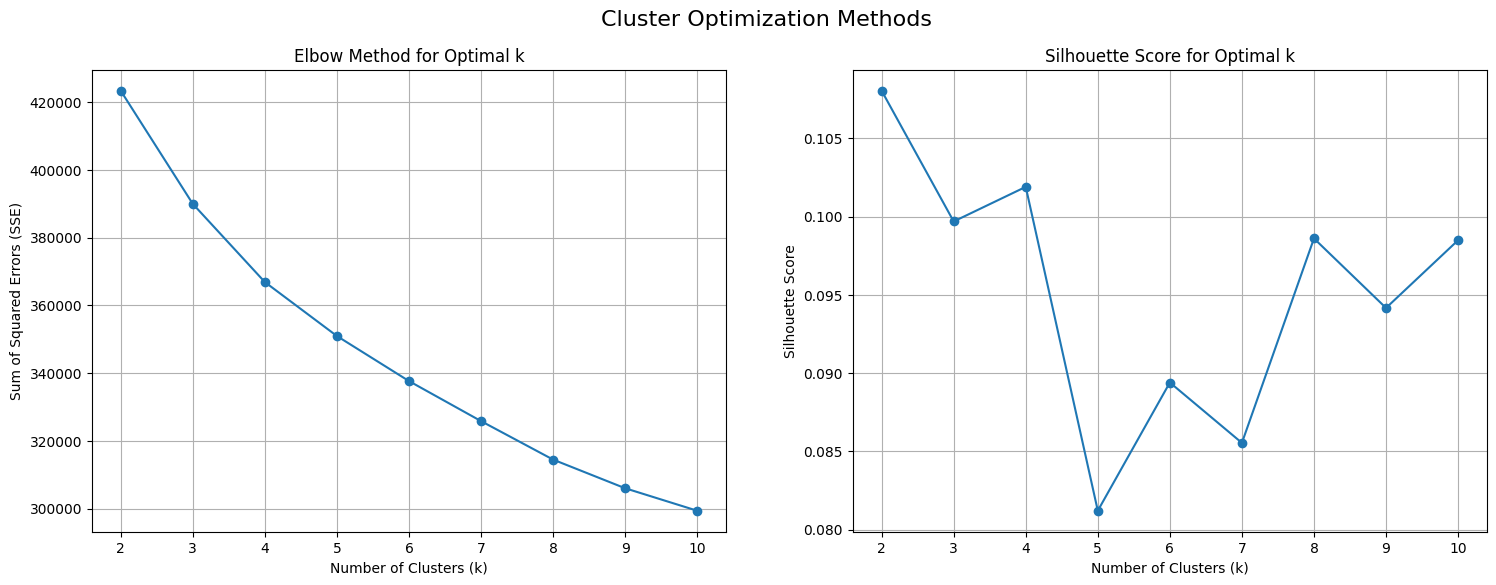

In [7]:
# Calculate SSE for Elbow Method and Silhouette Scores
sse = []
silhouette_scores = []
k_range = range(2, 11)  

for k in k_range:
    # K-Means for Elbow Method
    kmeans_elbow = KMeans(n_clusters=k, random_state=123, n_init=10)
    kmeans_elbow.fit(X_pca)
    sse.append(kmeans_elbow.inertia_)

    # K-Means for Silhouette Score
    kmeans_sil = KMeans(n_clusters=k, random_state=123, n_init=10)
    cluster_labels_sil = kmeans_sil.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, cluster_labels_sil)
    silhouette_scores.append(silhouette_avg)

# Plot Elbow Method and Silhouette Score Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Elbow Method Plot
ax1.plot(k_range, sse, marker="o")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Sum of Squared Errors (SSE)")
ax1.set_title("Elbow Method for Optimal k")
ax1.set_xticks(k_range)
ax1.grid(True)

# Silhouette Score Plot
ax2.plot(k_range, silhouette_scores, marker="o")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score for Optimal k")
ax2.set_xticks(k_range)
ax2.grid(True)

plt.suptitle("Cluster Optimization Methods", fontsize=16)
plt.show()


In [8]:
# Determine optimal k from each method
optimal_k_elbow = 4
# The optimal k for silhouette score is the one that maximizes the score
optimal_k_sil = k_range[np.argmax(silhouette_scores)]

print(f"Optimal k from Elbow Method: {optimal_k_elbow}")
print(f"Optimal k from Silhouette Score: {optimal_k_sil}")

# --- Horizontal Rule ---
print("\n" + "="*80 + "\n")

Optimal k from Elbow Method: 4
Optimal k from Silhouette Score: 2




# Full Analysis for k from Elbow Method (k=4)


In [9]:
print(f"--- Analysis for k = {optimal_k_elbow} (from Elbow Method) ---")

# K-Means Clustering
kmeans_elbow = KMeans(n_clusters=optimal_k_elbow, random_state=123, n_init=10)
cluster_labels_elbow = kmeans_elbow.fit_predict(X_pca)
df_aiming["aiming_strategy_elbow"] = cluster_labels_elbow
print(f"\nAssigned trials to {optimal_k_elbow} grip strategies based on Elbow Method.")

--- Analysis for k = 4 (from Elbow Method) ---

Assigned trials to 4 grip strategies based on Elbow Method.


C:\Users\bharg\AppData\Local\Temp\ipykernel_30460\2815584858.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


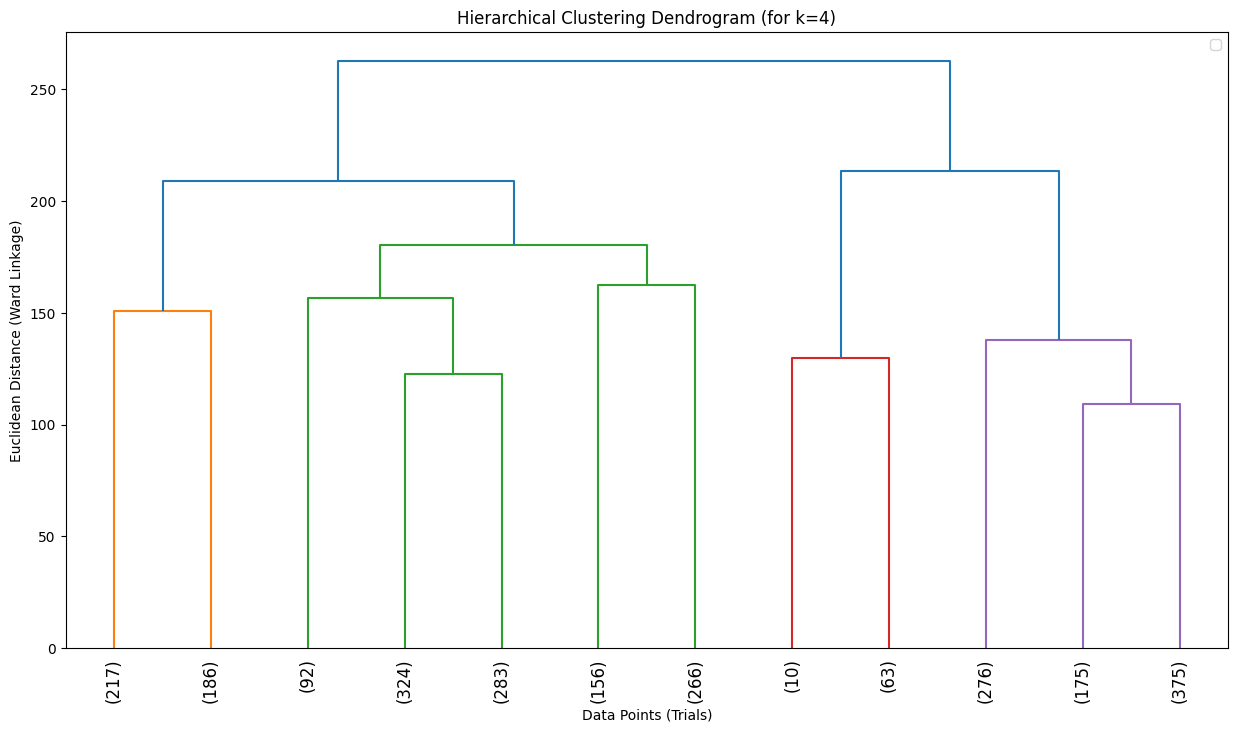

Assigned trials to 4 hierarchical strategies.


In [ ]:
# Hierarchical Clustering
linked_elbow = linkage(X_pca, method='ward')

plt.figure(figsize=(15, 8))
plt.title(f'Hierarchical Clustering Dendrogram (for k={optimal_k_elbow})')
plt.xlabel('Data Points (Trials)')
plt.ylabel('Euclidean Distance (Ward Linkage)')
dendrogram(linked_elbow, truncate_mode='lastp', p=12, show_leaf_counts=True, leaf_rotation=90., leaf_font_size=12.)
plt.legend()
plt.show()

hierarchical_cluster_elbow = AgglomerativeClustering(n_clusters=optimal_k_elbow, linkage='ward')
hierarchical_labels_elbow = hierarchical_cluster_elbow.fit_predict(X_pca)
df_aiming['hierarchical_strategy_elbow'] = hierarchical_labels_elbow
print(f"Assigned trials to {optimal_k_elbow} hierarchical strategies.")

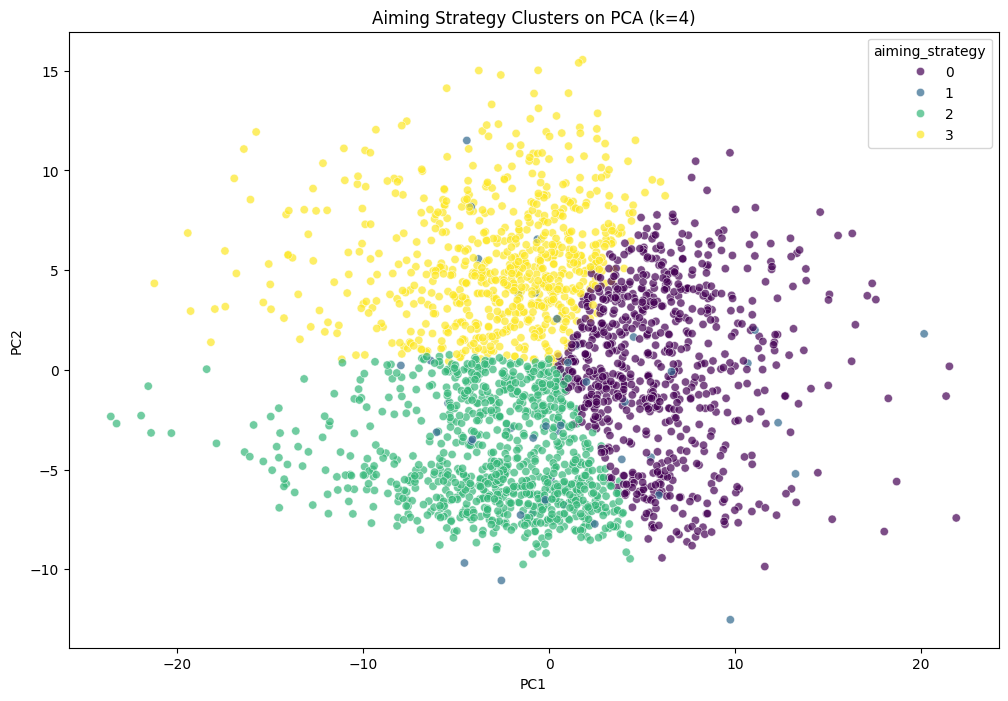


Relationship between K-Means strategies and 'distance':
distance               one  three  two
aiming_strategy_elbow                 
0                      155    278  302
1                       12     16   14
2                      642      2  265
3                        1    512  224


In [11]:
# Interpretation and Visualization
pca_df_elbow = pd.DataFrame(data=X_pca[:, :2], columns=["PC1", "PC2"])
pca_df_elbow["aiming_strategy"] = cluster_labels_elbow

plt.figure(figsize=(12, 8))
sns.scatterplot(x="PC1", y="PC2", hue="aiming_strategy", data=pca_df_elbow, palette="viridis", alpha=0.7)
plt.title(f"Aiming Strategy Clusters on PCA (k={optimal_k_elbow})")
plt.show()

print("\nRelationship between K-Means strategies and 'distance':")
print(pd.crosstab(df_aiming["aiming_strategy_elbow"], df_aiming["distance"]))


The PCA plot shows 4 clusters that are reasonably well-defined, though with more overlap than the prehension data. This is expected, as "aiming" might be a more continuous action than "grasping."

Aiming Strategy 0 (The "General-Purpose Aim"): This strategy is used across all distances, making it a versatile, "all-rounder" aiming movement. It's the most common strategy for the middle (two) and far (three) distances.

Aiming Strategy 1 (The "Anomalous Movement"): This cluster contains very few trials (12, 16, 14). This is an outlier cluster. It likely represents trials with tracking errors, subject mistakes, or simply highly unusual, non-standard movements that don't fit the main patterns.

Aiming Strategy 2 (The "Short-Range Point"): This is the most unambiguous strategy. It is used overwhelmingly for distance one (642 trials) and two (265 trials), and almost never for three. This is the primary strategy for close-range aiming.

Aiming Strategy 3 (The "Long-Range Lunge"): This strategy is the clear counterpart to strategy 2. It's used predominantly for distance three (512 trials) and two (224 trials), and essentially never for one. This is the strategy for far-range aiming.

In [12]:
# Comparative Analysis
print("\nCrosstab comparing K-Means labels vs. Hierarchical labels:")
print(pd.crosstab(df_aiming['aiming_strategy_elbow'], df_aiming['hierarchical_strategy_elbow']))

ari_score_elbow = adjusted_rand_score(df_aiming['aiming_strategy_elbow'], df_aiming['hierarchical_strategy_elbow'])
print(f"\nAdjusted Rand Index (ARI) between K-Means and Hierarchical: {ari_score_elbow:.4f}")



Crosstab comparing K-Means labels vs. Hierarchical labels:
hierarchical_strategy_elbow    0    1   2    3
aiming_strategy_elbow                         
0                            515   39   5  176
1                              1    1  40    0
2                            248   30  15  616
3                            357  333  13   34

Adjusted Rand Index (ARI) between K-Means and Hierarchical: 0.2225


K-Means and Hierarchical Clustering disagree significantly on how to form these four clusters. This confirms that these four "micro-strategies" have complex, non-spherical boundaries.

# Analysis for k from Silhouette Score (k=2)

In [13]:
print(f"\n\n--- Analysis for k = {optimal_k_sil} (from Silhouette Score) ---")

# K-Means Clustering
kmeans_sil = KMeans(n_clusters=optimal_k_sil, random_state=123, n_init=10)
cluster_labels_sil = kmeans_sil.fit_predict(X_pca)
df_aiming["aiming_strategy_sil"] = cluster_labels_sil
print(f"\nAssigned trials to {optimal_k_sil} grip strategies based on Silhouette Score.")




--- Analysis for k = 2 (from Silhouette Score) ---

Assigned trials to 2 grip strategies based on Silhouette Score.


C:\Users\bharg\AppData\Local\Temp\ipykernel_30460\971823035.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


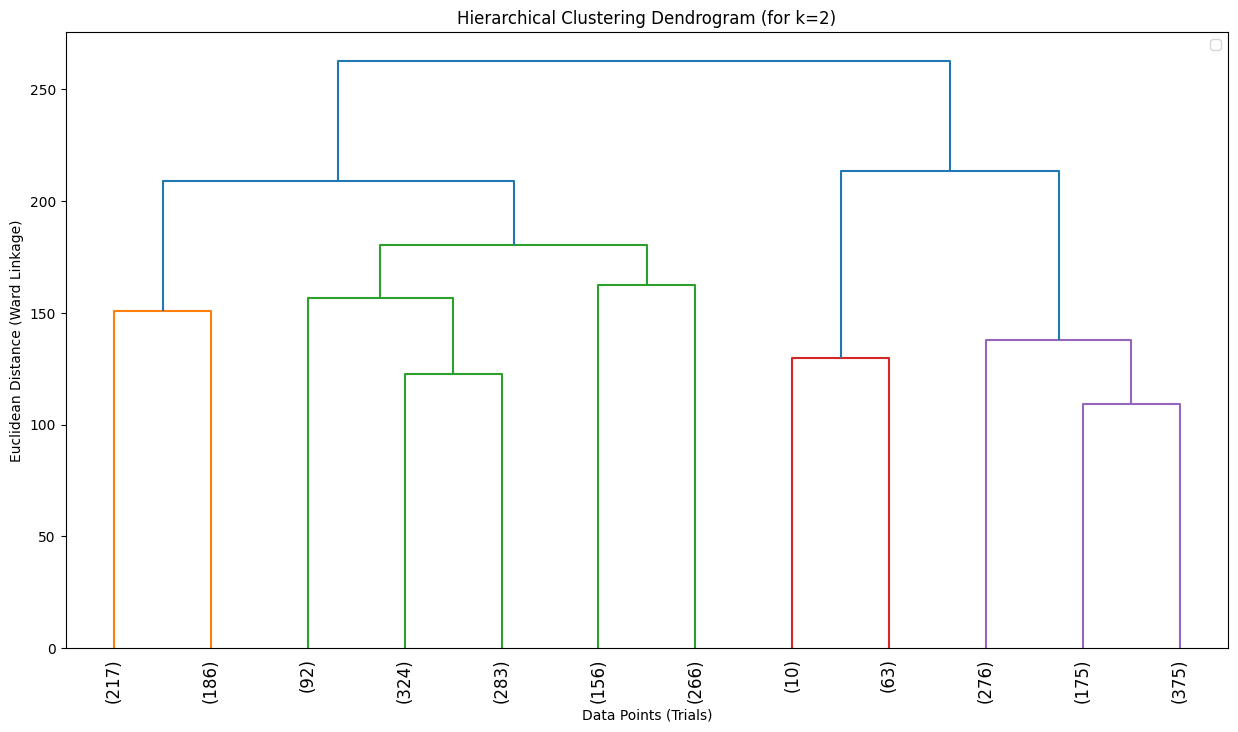

Assigned trials to 2 hierarchical strategies.


In [14]:
# Hierarchical Clustering
linked_sil = linkage(X_pca, method='ward')

plt.figure(figsize=(15, 8))
plt.title(f'Hierarchical Clustering Dendrogram (for k={optimal_k_sil})')
plt.xlabel('Data Points (Trials)')
plt.ylabel('Euclidean Distance (Ward Linkage)')
dendrogram(linked_sil, truncate_mode='lastp', p=12, show_leaf_counts=True, leaf_rotation=90., leaf_font_size=12.)
# The cut-off line is illustrative; you might need to adjust its position
# plt.axhline(y=450, c='k', linestyle='--', label='Cut-off line')
plt.legend()
plt.show()


hierarchical_cluster_sil = AgglomerativeClustering(n_clusters=optimal_k_sil, linkage='ward')
hierarchical_labels_sil = hierarchical_cluster_sil.fit_predict(X_pca)
df_aiming['hierarchical_strategy_sil'] = hierarchical_labels_sil
print(f"Assigned trials to {optimal_k_sil} hierarchical strategies.")

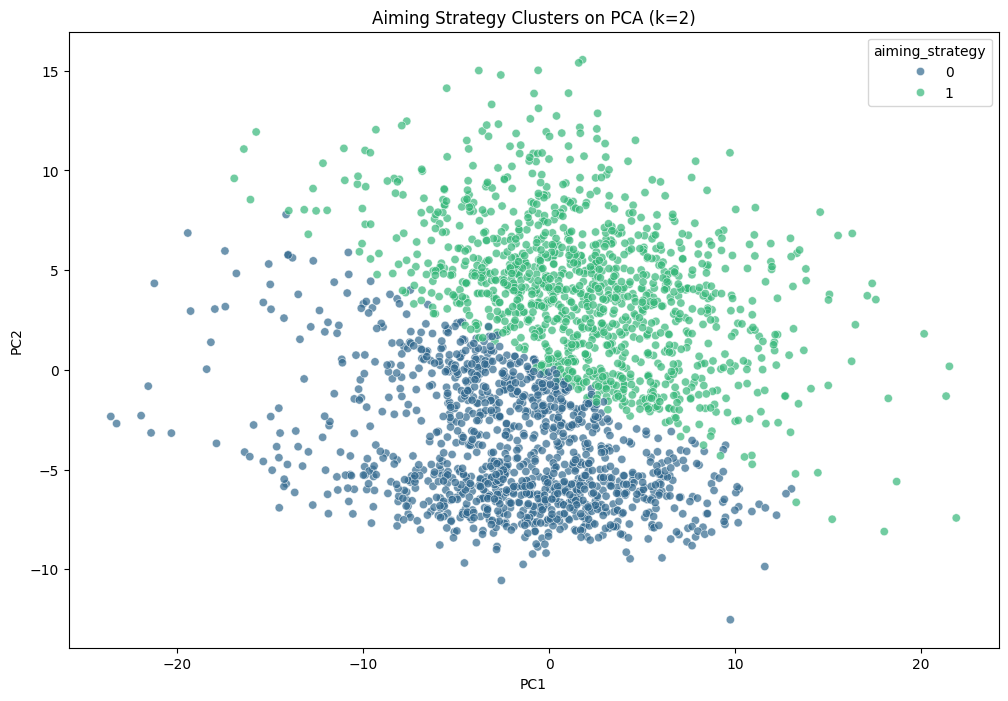


Relationship between K-Means strategies and 'distance':
distance             one  three  two
aiming_strategy_sil                 
0                    798      7  407
1                     12    801  398


In [15]:
# Interpretation and Visualization
pca_df_sil = pd.DataFrame(data=X_pca[:, :2], columns=["PC1", "PC2"])
pca_df_sil["aiming_strategy"] = cluster_labels_sil

plt.figure(figsize=(12, 8))
sns.scatterplot(x="PC1", y="PC2", hue="aiming_strategy", data=pca_df_sil, palette="viridis", alpha=0.7)
plt.title(f"Aiming Strategy Clusters on PCA (k={optimal_k_sil})")
plt.show()

print("\nRelationship between K-Means strategies and 'distance':")
print(pd.crosstab(df_aiming["aiming_strategy_sil"], df_aiming["distance"]))


Strategy 0: This strategy is used almost exclusively for distances one (798 trials) and two (407 trials), and almost never for three (7 trials).

Strategy 1: This strategy is used for distances two (398 trials) and three (801 trials), and rarely for one (12 trials).

In [16]:
# Comparative Analysis
print("\nCrosstab comparing K-Means labels vs. Hierarchical labels:")
print(pd.crosstab(df_aiming['aiming_strategy_sil'], df_aiming['hierarchical_strategy_sil']))

ari_score_sil = adjusted_rand_score(df_aiming['aiming_strategy_sil'], df_aiming['hierarchical_strategy_sil'])
print(f"\nAdjusted Rand Index (ARI) between K-Means and Hierarchical: {ari_score_sil:.4f}")


Crosstab comparing K-Means labels vs. Hierarchical labels:
hierarchical_strategy_sil    0     1
aiming_strategy_sil                 
0                          794   418
1                          105  1106

Adjusted Rand Index (ARI) between K-Means and Hierarchical: 0.3227


# Phase 2: Supervised Learning 


Cross Validation accracy scores for predicting distance: [1.         0.99455535 0.9978903  0.99530516 0.99765258]
Mean CV Accuracy: 0.9971 (+/- 0.0020)


C:\Users\bharg\AppData\Local\Temp\ipykernel_30460\3194073633.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


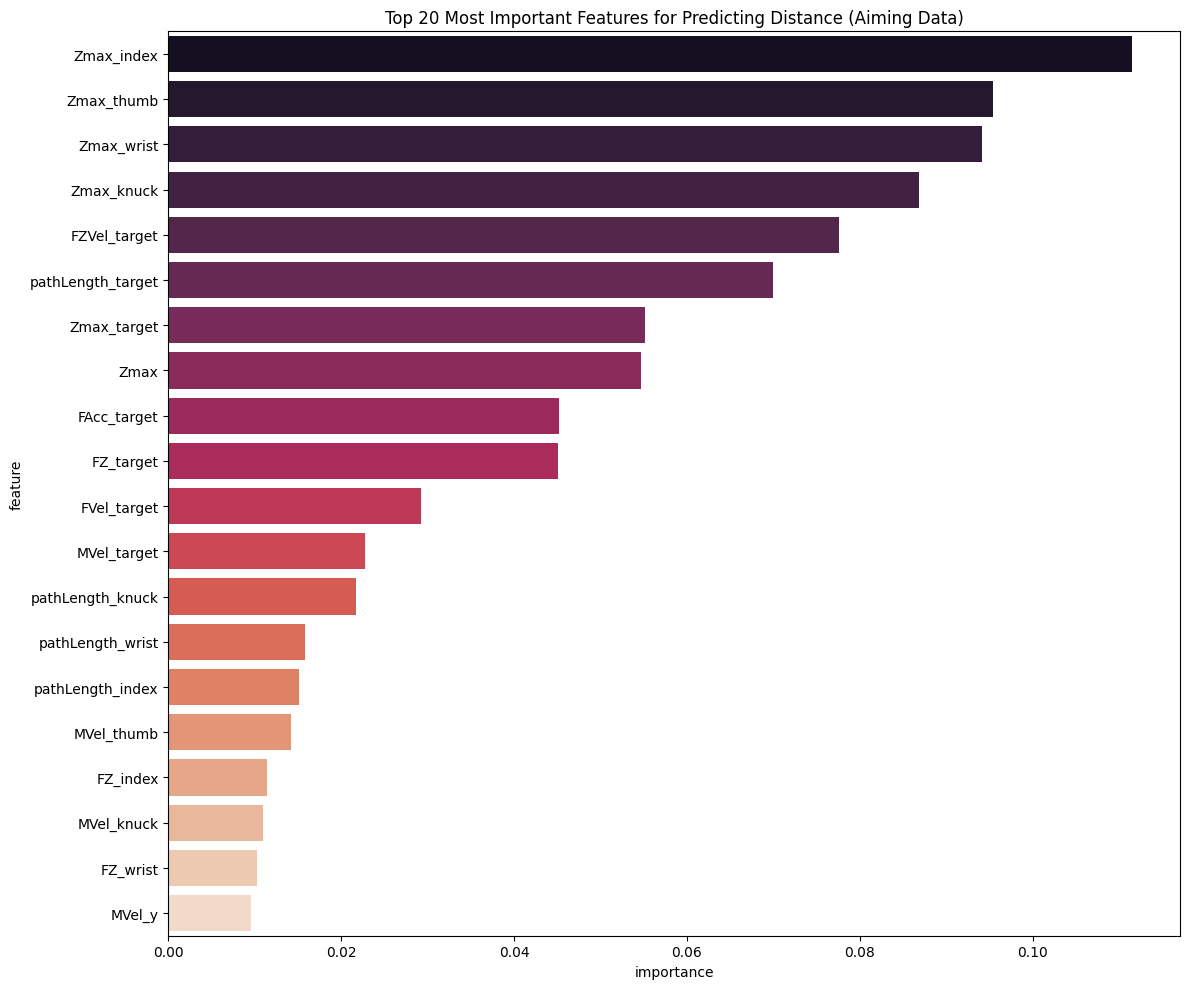

In [19]:
# Problem Formulation
X_supervised = df_aiming[kinematic_features]
y_supervised = df_aiming["distance"]

# Check if target variable exists
if y_supervised.isnull().all():
    print("Supervised target 'distance' not found or all null. Skipping supervised section.")
else:
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_supervised)

    # 2. Cross validation
    groups = df_aiming["subjName"]
    group_kfold = GroupKFold(n_splits=5)
    pipeline = Pipeline([
        ("scalar", StandardScaler()),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=123))
    ])
    cv_scores = cross_val_score(pipeline, X_supervised, y_encoded, cv=group_kfold, groups=groups)

    print(f"\nCross Validation accracy scores for predicting distance: {cv_scores}")
    print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

    # 3. Feature Importance
    pipeline.fit(X_supervised, y_encoded)
    importances = pipeline.named_steps['rf'].feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': kinematic_features,
        'importance': importances
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 10))
    sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
    plt.title('Top 20 Most Important Features for Predicting Distance (Aiming Data)')
    plt.tight_layout()
    plt.show()

The feature importance plot for the aiming data tells almost the exact same story as the prehension data.

Dominant Features: The top 5 features are all related to the maximum forward position (Zmax_index, Zmax_thumb, Zmax_wrist, Zmax_knuck) or forward velocity (FZVel_target).

Interpretation: For both grasping and aiming, the most predictive kinematic variable for how far a subject intends to move is the maximum forward extent of their reach. This robustly confirms that the brain plans the endpoint of the movement as a primary variable. The model finds this signal to be far stronger than speed (MVel) or acceleration (FAcc) for this specific predictive task.